## **_Sample Modeling V5.1_**
- for Reinforcement Learning
- using scikit-fuzzy
- pip install numpy pandas tensor ipykernel torch scikit-learn gymnasium stable_baselines3 scikit-fuzzy

In [1]:
!pip install scikit-fuzzy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------
import os
import sys
from pathlib import Path
from datetime import datetime

version = "v5.1"
csv_file_pathname = lambda: f".{os.sep}data{os.sep}fuzzy_dryer_sensor_{version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
model_path_name = lambda: f".{os.sep}model{os.sep}fuzzy_dryer_{version}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
global_num_samples = 51200
parent_dir = os.path.dirname(os.getcwd())
project_home_dir = str(Path.cwd().parent.parent)
venv_name = f"samplemodeling{version.replace('.', '_')}"

reward_gen_fn="lib/reward/dryer_oven/gen_reward_v1.py"
reward_gen_fn = reward_gen_fn.replace("/", os.sep)
reward_gen_fn_pythonfile = project_home_dir + os.sep + reward_gen_fn
simulation_cls_pathname = "lib/simulate/dryer_oven_simulation.py"
simulation_cls_pathname = simulation_cls_pathname.replace("/", os.sep)
simulation_cls_pathname = project_home_dir + os.sep + simulation_cls_pathname


In [3]:
# ----------------------------------------------------
# 개발 환경 초기화
# 한 번만 호출하여 주십시요.


# 1.1 set pythonpath to import from parent directory
def _init_environ():
    python_path = os.environ.get("PYTHONPATH")
    if python_path is None:
        python_path = ""
    sys.path.append(parent_dir)
    sys.path.append(project_home_dir)
    python_lib_path = [
        f'{project_home_dir}{os.sep}{venv_name}{os.sep}{"Lib" if sys.platform == "win32" else "lib"}{os.sep}site-packages',
        project_home_dir,
        python_path
    ]
    os.environ["PYTHONPATH"] = ";".join(python_lib_path)

    os.environ["CLEARML_WEB_HOST"] = "http://172.16.8.168:8080/"
    os.environ["CLEARML_API_HOST"] = "http://172.16.8.168:8008/"
    os.environ["CLEARML_FILES_HOST"] = "http://172.16.8.168:8081"
    os.environ["CLEARML_API_ACCESS_KEY"] = "SIJ8V8YP9PL25YEAVAWGP9NV11TMOQ"
    os.environ["CLEARML_API_SECRET_KEY"] = "6x_MEHvgrUv9-TFFDrE9BE7vb3JYOXDWq4kQtqbd58nQ5pqHEGMt6qQXxF7_HCyzq7E"

_init_environ()


In [4]:
!echo $PYTHONPATH
from lib.simulate.dryer_oven_data_genetate import generate_data_v1
from lib.simulate.dryer_oven_data_genetate_v2 import generate_data_v2

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25
drop_envs = [(0.4, 100, 30), (0.5, 200, 40)]
spike_envs = [(0.6, 300, 50), (0.7, 200, 40), (0.8, 200, 70)]
# drop_envs = []
# spike_envs = []

verbose = 0


gen_functions = {"v1": generate_data_v1, "v2": generate_data_v2}
cur_version = "v2"

stored_data_file_pathname = gen_functions[cur_version](drop_envs=drop_envs,
                                                       spike_envs=spike_envs,
                                                       csv_file_pathname=csv_file_pathname(),
                                                       num_samples=global_num_samples,
                                                       target_temp=target_temp,
                                                       initial_temp=initial_temp,
                                                       verbose=verbose)
print(f"Data stored in: {stored_data_file_pathname}")

/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks/samplemodelingv5_1/lib/site-packages;/home/jupyter-spire_modeler/work/mlops_jupyter_notebooks;
건조기 센서 가상 데이터 생성 완료!
데이터 샘플 (목표 온도: 80도):
Data stored in: ./data/fuzzy_dryer_sensor_v5.1_20260401_113848.csv


#### Step 2 Controller 생성

In [5]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

class FuzzyDryerController:
    def __init__(self):
        # 1. 퍼지 변수 설정
        # 입력: 오차(Error), 온도 변화율(Delta)
        self.error = ctrl.Antecedent(np.arange(-20, 21, 1), 'error')
        self.delta = ctrl.Antecedent(np.arange(-5, 6, 1), 'delta')
        # 출력: 팬 RPM 변화량(RPM_Adjust)
        self.rpm_adjust = ctrl.Consequent(np.arange(-300, 301, 1), 'rpm_adjust')

        # 2. 멤버십 함수 정의 (삼각형/사다리꼴)
        self.error['cold'] = fuzz.trapmf(self.error.universe, [-20, -20, -5, 0])
        self.error['target'] = fuzz.trimf(self.error.universe, [-2, 0, 2])
        self.error['hot'] = fuzz.trapmf(self.error.universe, [0, 5, 20, 20])

        self.delta['decreasing'] = fuzz.trimf(self.delta.universe, [-5, -5, 0])
        self.delta['stable'] = fuzz.trimf(self.delta.universe, [-1, 0, 1])
        self.delta['increasing'] = fuzz.trimf(self.delta.universe, [0, 5, 5])

        self.rpm_adjust['down'] = fuzz.trimf(self.rpm_adjust.universe, [-300, -300, 0])
        self.rpm_adjust['keep'] = fuzz.trimf(self.rpm_adjust.universe, [-50, 0, 50])
        self.rpm_adjust['up'] = fuzz.trimf(self.rpm_adjust.universe, [0, 300, 300])

        # 3. 퍼지 규칙(Rule) 설계
        rules = [
            ctrl.Rule(self.error['cold'], self.rpm_adjust['down']),      # 추우면 RPM 낮춰서 가열
            ctrl.Rule(self.error['hot'], self.rpm_adjust['up']),        # 더우면 RPM 높여서 냉각
            ctrl.Rule(self.error['target'] & self.delta['stable'], self.rpm_adjust['keep']), # 안정적이면 유지
            ctrl.Rule(self.error['hot'] & self.delta['increasing'], self.rpm_adjust['up']), # 더운데 계속 오르면 급격히 UP
            ctrl.Rule(self.error['cold'] & self.delta['decreasing'], self.rpm_adjust['down']) # 추운데 계속 떨어지면 급격히 DOWN
        ]

        self.control_sys = ctrl.ControlSystem(rules)
        self.simulator = ctrl.ControlSystemSimulation(self.control_sys)

    def get_action(self, current_temp, prev_temp, target=80.0):
        # 입력값 주입
        self.simulator.input['error'] = np.clip(current_temp - target, -20, 20)
        self.simulator.input['delta'] = np.clip(current_temp - prev_temp, -5, 5)
        
        # 퍼지 연산 실행
        self.simulator.compute()
        return self.simulator.output['rpm_adjust']


In [6]:
# --------------------------
# --- 물리 시뮬레이션 환경 ---

class DryerSimulator:
    def __init__(self):
        self.inner_temp = 25.0
        self.prev_temp = 25.0
        self.fan_rpm = 1500.0
        self.outer_temp = 20.0
        self.moisture = 1.0  # 100%
        self.weight = 5.0    # 5kg
        self.pressure = 1013.0

    def update(self, rpm_adjust):
        # 1. RPM 업데이트
        self.fan_rpm = np.clip(self.fan_rpm + rpm_adjust, 800, 3500)
        
        # 2. 압력 변화 (RPM 기반)
        self.pressure = 1013.0 + 0.000005 * (self.fan_rpm**2)
        
        # 3. 수분 및 무게 감소 (단순화 모델)
        evap = 0.0001 * self.moisture * (self.inner_temp - self.outer_temp)
        self.weight = max(4.0, self.weight - evap)
        self.moisture = max(0.0, (self.weight - 4.0) / 1.0)
        
        # 4. 온도 변화 (히터 - 냉각 - 증발)
        q_heater = 10.0
        q_cooling = (self.pressure / 1013.0) * (self.inner_temp - self.outer_temp) * 0.15
        q_evap = evap * 2000.0
        
        self.prev_temp = self.inner_temp
        self.inner_temp += (q_heater - q_cooling - q_evap)
        
        return self.inner_temp

##### 4. Test

hit_point = 16


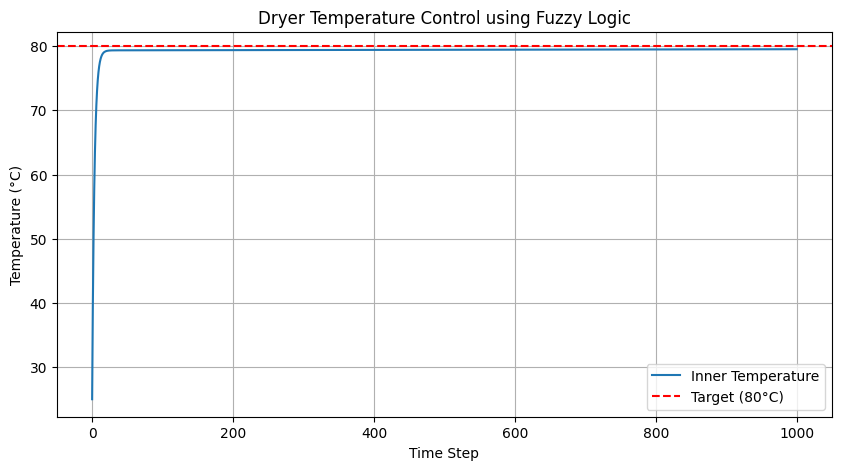

In [23]:
from lib.simulate.dryer_oven_simulation import DryerOvenSimulation
import torch
import matplotlib.pyplot as plt
from lib.types import unpack_nptype

max_repeat_cnt = 1000
initial_temp = 25.0
const_heater_input = 15.5

controller = FuzzyDryerController()

simulation = DryerOvenSimulation(use_ts=False,
                                 target_temp=80.0,
                                 initial_temp=initial_temp,
                                 initial_weight=80,
                                 dry_weight=20,
                                 debug=False)
init_state = [
            25.0,   # inner_temp 0
            -55.0,  # error      1
            80.0,   # humidity   2
            39.0,   # weight     3
            22.0,   # outer_temp 4
            1013.0, # pressure   5
            1500.0] # fan_rpm    6
history = []
state = init_state
prev_temp = unpack_nptype(state[0])
history.append(prev_temp)
inner_temp = prev_temp
convergence_cnt = 0
convergenced_cnt = 0
convergenced_stats = False
hit_point = 0

for i in range(max_repeat_cnt):
    # Fuzzy 제어기로부터 RPM 조절량 획득
    adjust = controller.get_action(inner_temp, prev_temp)
    # 물리 엔진 업데이트
    prev_temp = inner_temp
    state = simulation.step(action=adjust, state=state, heater_input=const_heater_input)
    state = list(state.values())
    inner_temp = unpack_nptype(state[0])    
    history.append(unpack_nptype(state[0]))
    
    # 수렴 위치 측정
    if abs(inner_temp - target_temp) < 1.5:
        convergenced_stats = True
        convergence_cnt += 1
        if convergence_cnt > 3 and convergenced_stats == True and hit_point == 0:
            convergenced_cnt
            hit_point = i
    else:
        convergenced_stats = False
        convergence_cnt = 0
        hit_point = 0


print(f'hit_point = {hit_point}')

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(history, label='Inner Temperature')
plt.axhline(y=80, color='r', linestyle='--', label='Target (80°C)')
plt.title('Dryer Temperature Control using Fuzzy Logic')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()
    